<a href="https://colab.research.google.com/github/riccricc91/AI-virtual-sensors/blob/main/electric_motor_temperature_LSTM_documented.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Permanent-Magnet Temperature Estimation with an LSTM–Conv1D Network

## Project overview

This project investigates **data-driven estimation of the permanent-magnet temperature (`pm`) of a Permanent Magnet Synchronous Motor (PMSM)** using a hybrid recurrent–convolutional neural network implemented in PyTorch.

Permanent-magnet temperature is an important internal motor state because excessive thermal stress can reduce magnet performance and, in severe conditions, contribute to irreversible demagnetization. Since rotor temperature is not always directly measurable in production applications, a virtual sensor based on quantities already available from the electric drive can provide a useful alternative.

The notebook focuses on a **Many-to-One** formulation: a temporal window of electrical, mechanical and thermal-boundary-condition variables is processed to estimate the PM temperature at the final sample of the window. The adopted model combines an LSTM, which extracts temporal dependencies, with a Conv1D layer and temporal mean pooling before the final regression head.

The workflow includes exploratory data analysis, physics-inspired feature engineering, profile-based train/validation/test splitting, normalization, profile-safe temporal window generation, model training with regularization and early stopping, and evaluation both globally and separately for each test profile.


## Dataset description

The dataset used in this notebook is the **Electric Motor Temperature** dataset published on Kaggle. Test bench measurements were collected by the LEA department at Paderborn University. It contains measurements collected from a PMSM under multiple operating profiles. Each sample describes the electrical, mechanical and thermal state of the motor, while `profile_id` identifies the experimental operating profile to which the sample belongs.

### Original variables

| Variable | Meaning | Role |
|---|---|---|
| `ambient` | Ambient temperature | Thermal boundary condition |
| `coolant` | Coolant temperature | Thermal boundary condition / cooling-system state |
| `u_d` | d-axis stator voltage | Electrical operating condition |
| `u_q` | q-axis stator voltage | Electrical operating condition |
| `i_d` | d-axis stator current | Field/flux-related current component |
| `i_q` | q-axis stator current | Torque-related current component |
| `motor_speed` | Rotor rotational speed | Mechanical operating condition |
| `torque` | Motor torque | Mechanical load |
| `stator_yoke` | Stator-yoke temperature | Measured internal thermal state |
| `stator_tooth` | Stator-tooth temperature | Measured internal thermal state |
| `stator_winding` | Stator-winding temperature | Measured internal thermal state |
| `pm` | Permanent-magnet temperature | **Prediction target** |
| `profile_id` | Operating-profile identifier | Keeps independent experiments separated |

The electrical quantities are expressed in the rotating **d–q reference frame**, commonly used for PMSM control. In simplified terms, the d-axis is mainly associated with flux control, whereas the q-axis is strongly related to torque production.

In addition to the original variables, this notebook derives physics-inspired quantities from currents, voltages, speed and torque. These derived features do not introduce new measurements, but provide the network with representations that are directly related to electrical loading and mechanical operating conditions.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader,
    ConcatDataset
)

import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
 #   for filename in filenames:
  #      print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
main_dir = '/content/drive/MyDrive/Datasets/measures_v2.csv'

## 1. Data loading and preliminary inspection

The dataset is first loaded into a pandas DataFrame. Shape, data types and missing values are inspected before modelling. This step is essential for detecting incomplete variables, unexpected data types, or inconsistencies that could propagate into the neural network.


In [4]:
df = pd.read_csv(main_dir)
df.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


In [5]:
df.columns

Index(['u_q', 'coolant', 'stator_winding', 'u_d', 'stator_tooth',
       'motor_speed', 'i_d', 'i_q', 'pm', 'stator_yoke', 'ambient', 'torque',
       'profile_id'],
      dtype='object')

In [6]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Dataset shape: (1330816, 13)

Data types:
u_q               float64
coolant           float64
stator_winding    float64
u_d               float64
stator_tooth      float64
motor_speed       float64
i_d               float64
i_q               float64
pm                float64
stator_yoke       float64
ambient           float64
torque            float64
profile_id          int64
dtype: object


In [7]:
df.isna().sum()

,0
u_q,0
coolant,0
stator_winding,0
u_d,0
stator_tooth,0
motor_speed,0
i_d,0
i_q,0
pm,0
stator_yoke,0


In [8]:
df["current_mag"] = np.sqrt(
    df["i_d"]**2 +
    df["i_q"]**2
)

df["current_sq"] = (
    df["i_d"]**2 +
    df["i_q"]**2
)

df["omega"] = (
    df["motor_speed"] *
    2 * np.pi / 60
)

df["mechanical_power"] = (
    df["torque"] *
    df["omega"]
)

df["voltage_mag"] = np.sqrt(
    df["u_d"]**2 +
    df["u_q"]**2
)

## 2. Exploratory data analysis

A correlation matrix provides a first overview of linear relationships among electrical, mechanical and thermal quantities, including the engineered features. Correlation is used here as an exploratory tool rather than as evidence of causality. The operating signals are also inspected in the time domain to visualize the diversity of motor regimes contained in the dataset.


<Axes: >

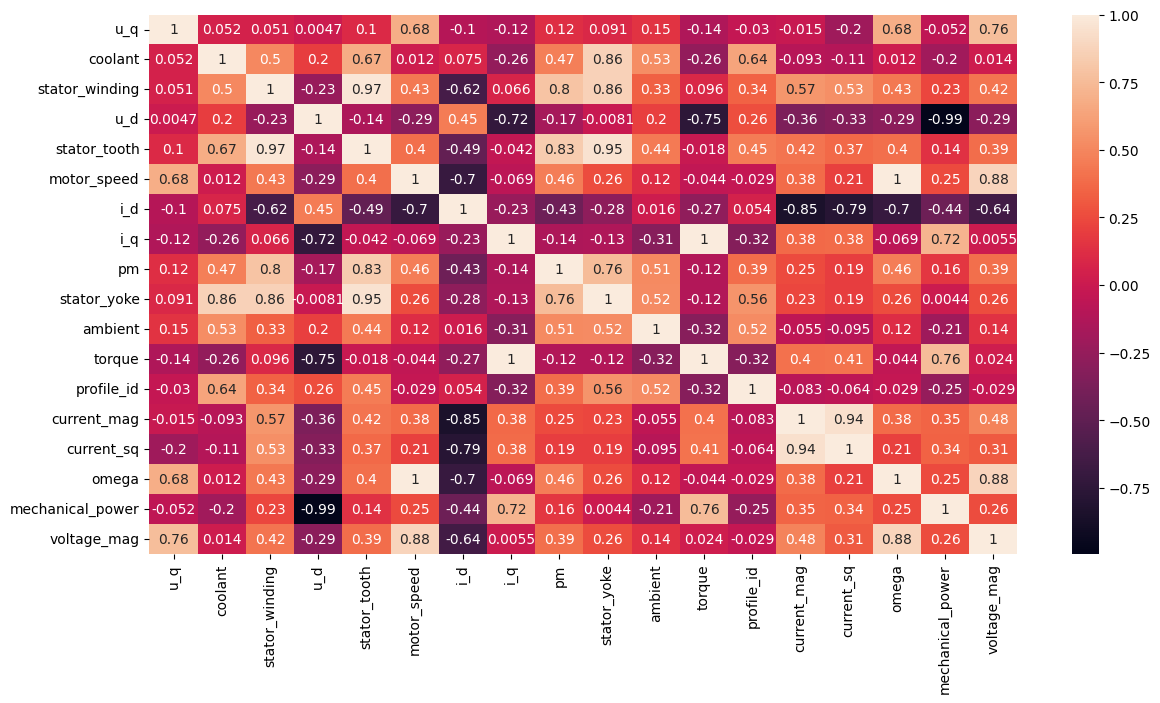

In [9]:
plt.figure(figsize=(14,7))
sns.heatmap(df.corr(),annot=True)

## 3. Target selection and feature engineering

The prediction target is `pm`, the permanent-magnet temperature. Several candidate feature sets are retained in the code to make future ablation studies straightforward, while the model developed in this notebook uses **`features_4`**, for a total of **12 input features**.

The selected inputs are the eight directly measured operating variables `ambient`, `coolant`, `u_d`, `u_q`, `motor_speed`, `torque`, `i_d` and `i_q`, together with four derived quantities:

- `current_mag = sqrt(i_d² + i_q²)`, the magnitude of the d–q current vector;
- `current_sq = i_d² + i_q²`, a current-squared indicator related to electrical loading;
- `voltage_mag = sqrt(u_d² + u_q²)`, the magnitude of the d–q voltage vector;
- `mechanical_power = torque × omega`, with `omega = motor_speed × 2π/60`.

The three stator temperatures are intentionally **not included in the active feature set**. This keeps the estimator based on operating variables and thermal boundary conditions rather than directly measured internal stator temperatures.


In [10]:
#target temperatura magneti permanenti
target = "pm"

features_1 = [
    "ambient",
    "coolant",
    "motor_speed",
    "torque",
    "i_d",
    "i_q"
]

features_2 = [
    "ambient",
    "coolant",
    "u_d",
    "u_q",
    "motor_speed",
    "torque",
    "i_d",
    "i_q"
]

features_3 = [
    "ambient",
    "coolant",
    "u_d",
    "u_q",
    "motor_speed",
    "torque",
    "i_d",
    "i_q",
    "stator_yoke",
    "stator_tooth",
    "stator_winding"
]

features_4 = [
    "ambient",
    "coolant",
    "u_d",
    "u_q",
    "motor_speed",
    "torque",
    "i_d",
    "i_q",
    "current_mag",
    "current_sq",
    "voltage_mag",
    "mechanical_power"
]

features = features_4


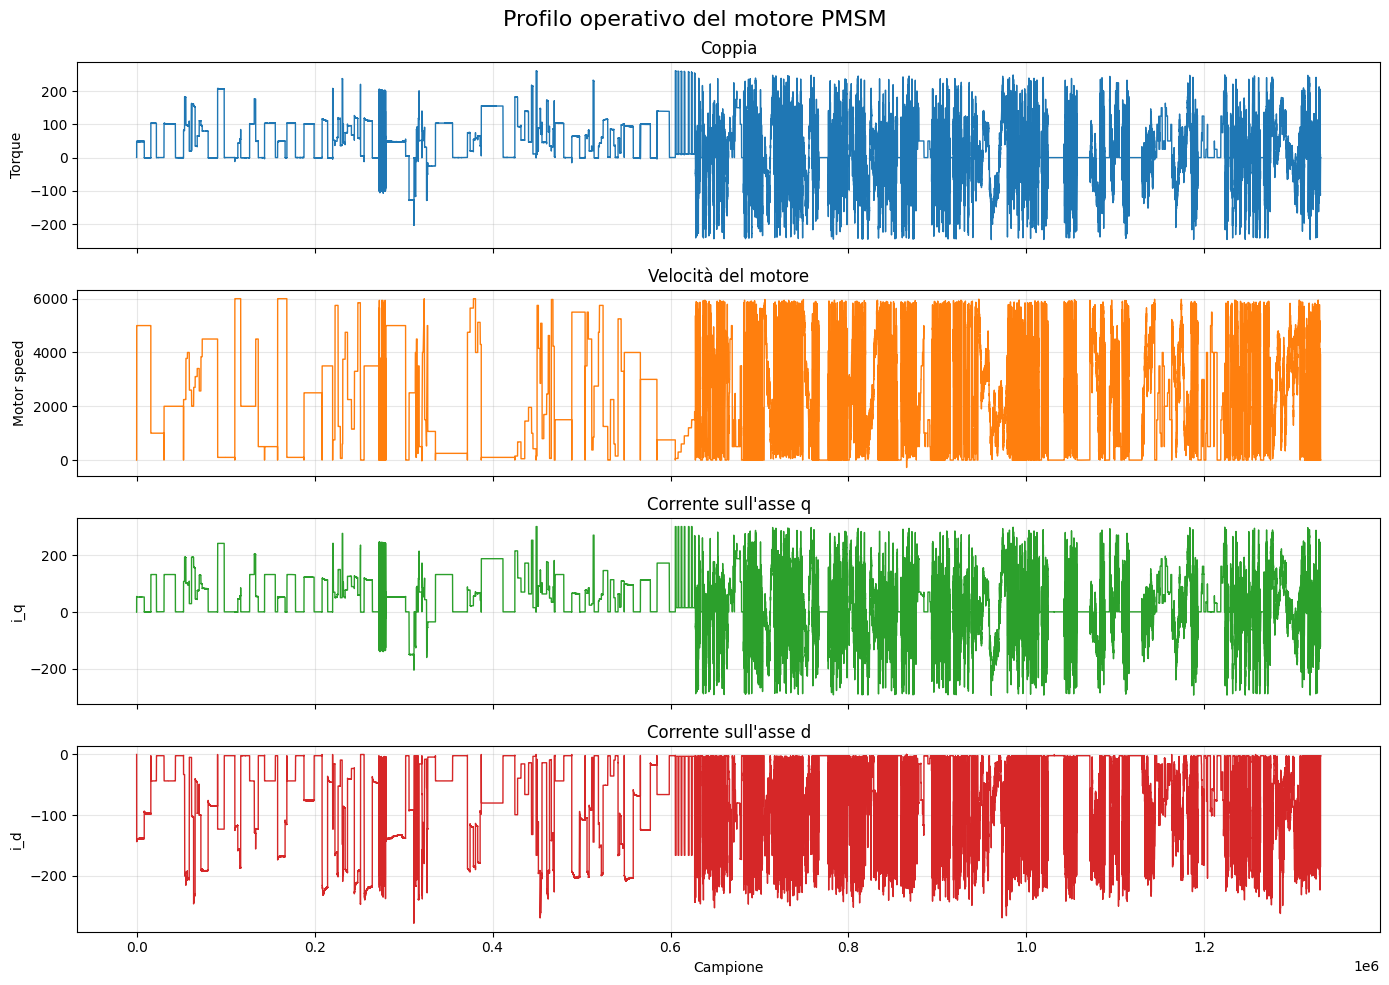

In [11]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(14, 10),
    sharex=True
)

# Coppia
axes[0].plot(
    df["torque"],
    color="tab:blue",
    linewidth=1
)
axes[0].set_ylabel("Torque")
axes[0].set_title("Coppia")
axes[0].grid(True, alpha=0.3)

# Velocità
axes[1].plot(
    df["motor_speed"],
    color="tab:orange",
    linewidth=1
)
axes[1].set_ylabel("Motor speed")
axes[1].set_title("Velocità del motore")
axes[1].grid(True, alpha=0.3)

# Corrente q
axes[2].plot(
    df["i_q"],
    color="tab:green",
    linewidth=1
)
axes[2].set_ylabel("i_q")
axes[2].set_title("Corrente sull'asse q")
axes[2].grid(True, alpha=0.3)

# Corrente d
axes[3].plot(
    df["i_d"],
    color="tab:red",
    linewidth=1
)
axes[3].set_ylabel("i_d")
axes[3].set_xlabel("Campione")
axes[3].set_title("Corrente sull'asse d")
axes[3].grid(True, alpha=0.3)

plt.suptitle(
    "Profilo operativo del motore PMSM",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 4. Profile-based train/validation/test split

The dataset is **not a single continuous experiment**. It contains multiple independent operating tests identified by `profile_id`. The split is therefore performed at profile level rather than by randomly splitting individual rows.

This methodological choice prevents samples from the same operating profile from appearing in both training and test sets. Since adjacent time samples are strongly correlated, a row-wise random split could otherwise lead to information leakage and overly optimistic performance estimates.

The profiles are shuffled reproducibly with a fixed random seed and divided approximately into **70% training, 15% validation and 15% test**. In the current split this corresponds to 48 training profiles, 10 validation profiles and 11 test profiles.


In [12]:
profiles = df["profile_id"].unique()
print(profiles)

[17  5 12 32 21  2  4  7 19  3  9 23 27 26 11  6 10 13 31 18 30 29  8 24
 20 15 14 16 36 74 75 41 68 50 53 49 81 80 59 54 57 70 51 55 45 69 61 76
 56 64 72 73 62 65 63 43 47 66 42 48 67 44 79 52 60 46 58 78 71]


In [13]:
# Mescolamento riproducibile
np.random.seed(42)
np.random.shuffle(profiles)

# Divisione 70% - 15% - 15%
n_profiles = len(profiles)

n_train = int(0.70 * n_profiles)
n_validation = int(0.15 * n_profiles)

train_profiles = profiles[:n_train]

validation_profiles = profiles[
    n_train:n_train + n_validation
]

test_profiles = profiles[
    n_train + n_validation:
]

In [14]:
train_df = df[
    df["profile_id"].isin(train_profiles)
].reset_index(drop=True)

validation_df = df[
    df["profile_id"].isin(validation_profiles)
].reset_index(drop=True)

test_df = df[
    df["profile_id"].isin(test_profiles)
].reset_index(drop=True)

In [15]:
print("Train profiles:", len(train_profiles))
print("Validation profiles:", len(validation_profiles))
print("Test profiles:", len(test_profiles))

print("\nNumero di righe:")
print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Train profiles: 48
Validation profiles: 10
Test profiles: 11

Numero di righe:
Train: 903590
Validation: 243502
Test: 183724


In [16]:
x_train = train_df[features]
y_train = train_df[target]

x_validation = validation_df[features]
y_validation = validation_df[target]

x_test = test_df[features]
y_test = test_df[target]

print("Train Features --> ", x_train.shape)
print("Validation Features --> ", x_validation.shape)
print("Test Features --> ", x_test.shape)

print("Train Target --> ", y_train.shape)
print("Validation Target --> ", y_validation.shape)
print("Test Target --> ", y_test.shape)

Train Features -->  (903590, 12)
Validation Features -->  (243502, 12)
Test Features -->  (183724, 12)
Train Target -->  (903590,)
Validation Target -->  (243502,)
Test Target -->  (183724,)


## 5. Feature and target normalization

The input variables have substantially different physical scales, so `StandardScaler` is used to standardize them before training. Both the input scaler and target scaler are fitted **only on the training set** and are then applied unchanged to validation and test data.

This prevents information leakage from validation or test data into preprocessing. A separate scaler is used for `pm`, allowing network outputs to be transformed back to degrees Celsius for final evaluation.


In [17]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_train = x_scaler.fit_transform(train_df[features])
x_valid = x_scaler.transform(validation_df[features])
x_test = x_scaler.transform(test_df[features])

y_train = y_scaler.fit_transform(
    train_df[[target]]
).squeeze()

y_validation = y_scaler.transform(
    validation_df[[target]]
).squeeze()

y_test = y_scaler.transform(
    test_df[[target]]
).squeeze()

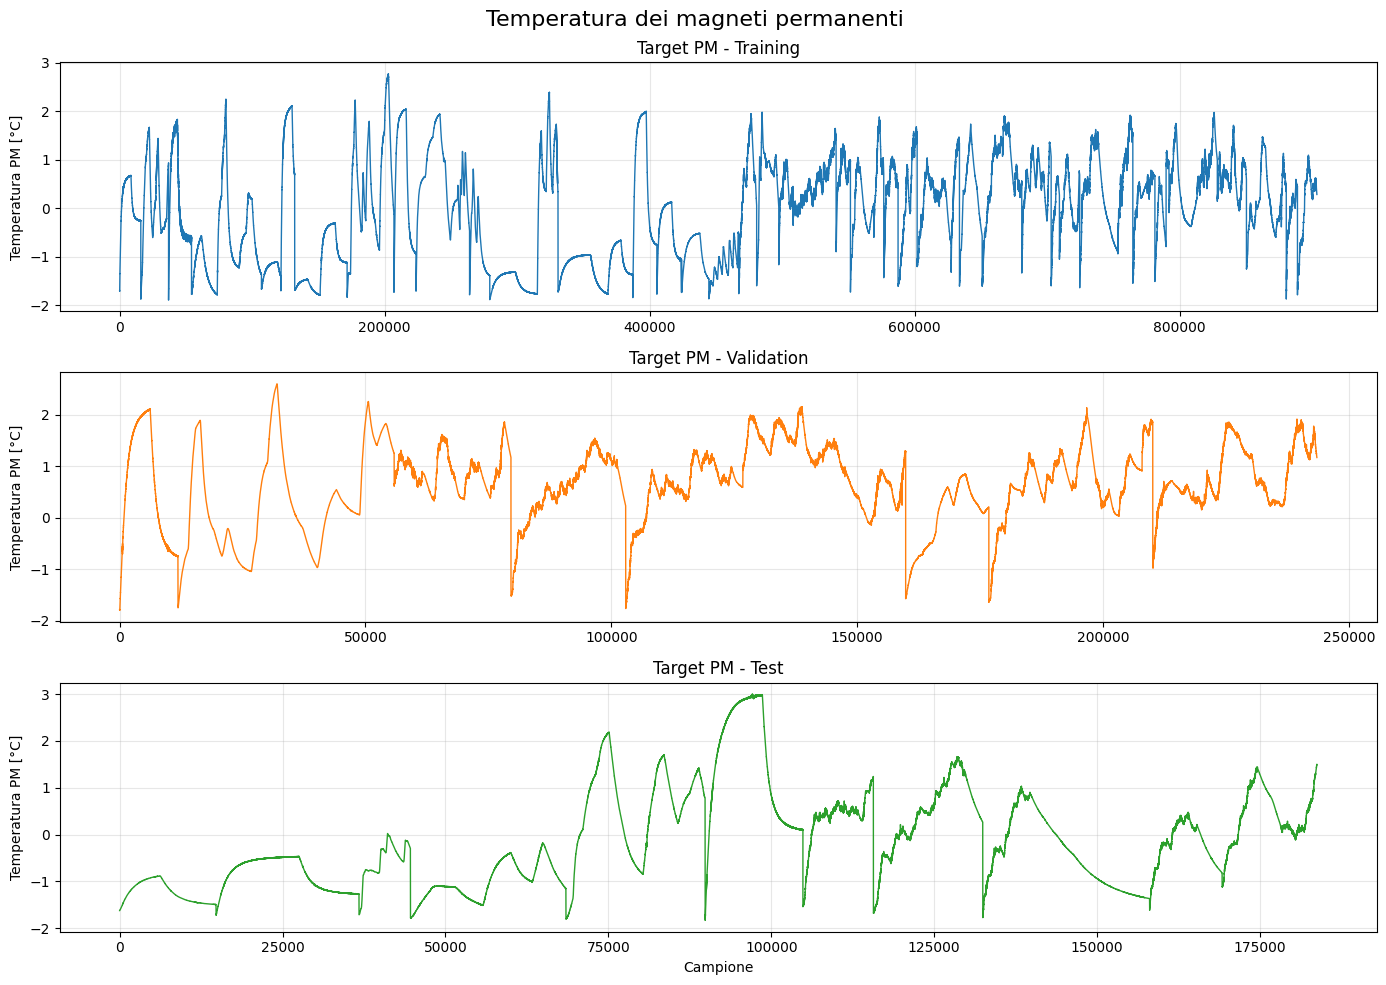

In [18]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14, 10)
)

# Training
axes[0].plot(
    y_train,
    color="tab:blue",
    linewidth=1
)
axes[0].set_title("Target PM - Training")
axes[0].set_ylabel("Temperatura PM [°C]")
axes[0].grid(True, alpha=0.3)

# Validation
axes[1].plot(
    y_validation,
    color="tab:orange",
    linewidth=1
)
axes[1].set_title("Target PM - Validation")
axes[1].set_ylabel("Temperatura PM [°C]")
axes[1].grid(True, alpha=0.3)

# Test
axes[2].plot(
    y_test,
    color="tab:green",
    linewidth=1
)
axes[2].set_title("Target PM - Test")
axes[2].set_xlabel("Campione")
axes[2].set_ylabel("Temperatura PM [°C]")
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    "Temperatura dei magneti permanenti",
    fontsize=16
)

plt.tight_layout()
plt.show()

# Model A — Many-to-One LSTM–Conv1D

## 6. Time-series windowing

Each model input is a temporal window with shape

`[window_size, number_of_features]`

and the target is the PM temperature at the **last sample of that window**.

The final configuration uses `window_size = 2000` and `stride = 100`. Consecutive windows therefore overlap substantially. The long observation horizon was selected to provide the network with a broad history of operating conditions, which is particularly relevant for a thermal state whose evolution depends on heat accumulated over time.

Windows are generated **separately inside each `profile_id`** and only then concatenated into the train, validation and test datasets. No window is therefore allowed to cross the boundary between two independent experiments. With the current split and windowing parameters, the datasets contain 8101 training windows, 2240 validation windows and 1623 test windows.


In [19]:
class TimeSeriesDataset():
    def __init__(
        self,
        features,
        targets,
        window_size=100,
        stride=100
    ):

        self.features = torch.as_tensor(
            np.asarray(features),
            dtype=torch.float32
        )

        self.targets = torch.as_tensor(
            np.asarray(targets),
            dtype=torch.float32
        )

        self.window_size = window_size
        self.stride = stride

        if len(self.features) != len(self.targets):
            raise ValueError(
                "Features e target devono avere lo stesso numero di campioni."
            )

        if window_size > len(self.features):
            raise ValueError(
                "window_size è maggiore della lunghezza della serie."
            )

        self.num_windows = (
            (len(self.features) - window_size)
            // stride
            + 1
        )

    def __len__(self):
        return self.num_windows

    def __getitem__(self, index):

        start = index * self.stride
        end = start + self.window_size

        x_window = self.features[start:end]

        # Target corrispondente all'ultimo istante della finestra
        y_target = self.targets[end - 1].reshape(1)

        return x_window, y_target

In [20]:
window_size = 2000
stride = 100


def build_profile_dataset_many_to_one(split_df, feature_scaler, target_scaler, features, target, window_size, stride):
    """Create one TimeSeriesDataset per profile and concatenate them.

    Keeping profiles separate prevents a temporal window from crossing the
    boundary between two independent experiments.
    """
    datasets = []

    for profile_id, profile_df in split_df.groupby("profile_id", sort=False):
        x_profile = feature_scaler.transform(profile_df[features])
        y_profile = target_scaler.transform(profile_df[[target]]).squeeze()

        if len(profile_df) >= window_size:
            datasets.append(
                TimeSeriesDataset(
                    features=x_profile,
                    targets=y_profile,
                    window_size=window_size,
                    stride=stride,
                )
            )

    if not datasets:
        raise ValueError("No profile is long enough for the selected window_size.")

    return ConcatDataset(datasets)


train_dataset = build_profile_dataset_many_to_one(
    train_df, x_scaler, y_scaler, features, target, window_size, stride
)
validation_dataset = build_profile_dataset_many_to_one(
    validation_df, x_scaler, y_scaler, features, target, window_size, stride
)
test_dataset = build_profile_dataset_many_to_one(
    test_df, x_scaler, y_scaler, features, target, window_size, stride
)


In [21]:
print("Numero finestre train:", len(train_dataset))
print("Numero finestre validation:", len(validation_dataset))
print("Numero finestre test:", len(test_dataset))

Numero finestre train: 8101
Numero finestre validation: 2240
Numero finestre test: 1623


In [22]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

In [23]:
(
    x_batch,
    y_batch,
) = next(iter(train_loader))

print("x_batch:", x_batch.shape)
print("y_batch:", y_batch.shape)

x_batch: torch.Size([32, 2000, 12])
y_batch: torch.Size([32, 1])


In [24]:
import torch
import torch.nn as nn

## 7. Many-to-One network architecture

The model combines recurrent and convolutional processing. First, a **two-layer LSTM** processes the complete input window and produces a hidden representation at every time step. The sequence of LSTM hidden states is then rearranged and processed by a **one-dimensional convolution**, which extracts local patterns from the learned temporal representation.

A **temporal mean-pooling** operation averages the Conv1D feature maps over the time dimension, producing one fixed-size representation for the complete observation window. This representation is passed through a fully connected regression head to produce a single PM-temperature estimate.

For the current configuration, the network uses 12 input features, an LSTM hidden size of 64, 2 recurrent layers, 32 Conv1D channels with kernel size 3, a 32-neuron fully connected layer, and dropout of 0.3. The architecture can therefore be summarized as:

`Input window → LSTM → Conv1D + ReLU → temporal mean pooling → FC + ReLU + Dropout → PM temperature`

Unlike a formulation that uses only the final LSTM output, temporal mean pooling allows information from the Conv1D representation across the complete window to contribute to the final regression.


In [25]:
import torch
import torch.nn as nn


class TemperatureLSTM(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        conv_channels,
        kernel_size,
        neurons,
        dropout_p
    ):
        super().__init__()

        # ======================================================
        # 1. LSTM
        # ======================================================

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_p if num_layers > 1 else 0
        )


        # ======================================================
        # 2. CONV1D
        # ======================================================

        self.conv1 = nn.Conv1d(
            in_channels=hidden_size,
            out_channels=conv_channels,
            kernel_size=kernel_size,
            padding="same"
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(dropout_p)


        # ======================================================
        # 3. FULLY CONNECTED
        # ======================================================

        self.fc1 = nn.Linear(
            conv_channels,
            neurons
        )

        self.fc2 = nn.Linear(
            neurons,
            1
        )


    def forward(self, x):

        # ======================================================
        # INPUT
        # ======================================================

        # x:
        # [batch, time, features]


        # ======================================================
        # 1. LSTM
        # ======================================================

        out, _ = self.lstm(x)

        # out:
        # [batch, time, hidden_size]


        # ======================================================
        # 2. CONV1D
        # ======================================================

        # Conv1D vuole:
        # [batch, channels, time]

        out = out.permute(0, 2, 1)

        # out:
        # [batch, hidden_size, time]


        out = self.conv1(out)
        out = self.relu(out)

        # out:
        # [batch, conv_channels, time]


        # ======================================================
        # 3. TEMPORAL MEAN POOLING
        # ======================================================

        out = torch.mean(out, dim=2) #out = out[:, :, -1] ultimo timestep è:

        # out:
        # [batch, conv_channels]


        # ======================================================
        # 4. FULLY CONNECTED
        # ======================================================

        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.fc2(out)

        # out:
        # [batch, 1]

        return out

In [26]:
print(x_train.shape[1])

12


In [27]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = TemperatureLSTM(
    input_size=x_train.shape[1],
    hidden_size=64,
    num_layers=2,
    conv_channels=32,
    kernel_size=3,
    neurons=32,
    dropout_p=0.3
)

#criterion = nn.MSELoss()
criterion = nn.HuberLoss(delta=1.0)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


Device: cpu


In [28]:
print(f"{'='*30}\nInitialized Model Architecture\n{'='*30}\n{model}")
print(f"\n{'='*30}\nOptimizer\n{'='*30}\n{optimizer}")
print(f"\n{'='*30}\nLoss Function\n{'='*30}\n{criterion}")

Initialized Model Architecture
TemperatureLSTM(
  (lstm): LSTM(12, 64, num_layers=2, batch_first=True, dropout=0.3)
  (conv1): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=same)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=32, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

Optimizer
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)

Loss Function
HuberLoss()


## 8. Training strategy

The network is trained with the **Huber loss** (`nn.HuberLoss(delta=1.0)`), which behaves quadratically for small residuals and more linearly for large residuals. This provides a regression objective that is less dominated by large errors than pure MSE.

Optimization is performed with **Adam**. Dropout is also applied in the recurrent network and regression head.

Whenever validation loss improves, the corresponding model parameters are saved to `best_model.pth`. The best saved parameters are restored before test evaluation, so test metrics refer to the best validation checkpoint rather than necessarily to the final training epoch.



In [29]:
num_epochs = 100

train_losses = []
validation_losses = []

best_val_loss = float("inf")
patience = 7
counter = 0

for epoch in range(num_epochs):

    # ==========================
    # TRAINING
    # ==========================
    model.train()
    train_loss = 0.0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(x_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ==========================
    # VALIDATION
    # ==========================
    model.eval()
    validation_loss = 0.0

    with torch.no_grad():

        for x_batch, y_batch in validation_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(x_batch)

            loss = criterion(predictions, y_batch)

            validation_loss += loss.item()

    validation_loss /= len(validation_loader)

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Validation Loss: {validation_loss:.6f}"
    )


    # ==========================
    # EARLY STOPPING
    # ==========================

    if validation_loss < best_val_loss:

        best_val_loss = validation_loss
        counter = 0

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

    else:

        counter += 1

        if counter >= patience:
            print("Early stopping")
            break

Epoch [1/100] Train Loss: 0.096856 Validation Loss: 0.039335
Epoch [2/100] Train Loss: 0.049033 Validation Loss: 0.042310
Epoch [3/100] Train Loss: 0.045104 Validation Loss: 0.045117
Epoch [4/100] Train Loss: 0.041085 Validation Loss: 0.040102
Epoch [5/100] Train Loss: 0.042211 Validation Loss: 0.043276
Epoch [6/100] Train Loss: 0.041114 Validation Loss: 0.044907
Epoch [7/100] Train Loss: 0.039824 Validation Loss: 0.041478
Epoch [8/100] Train Loss: 0.041083 Validation Loss: 0.042136
Early stopping


In [30]:
model.load_state_dict(
    torch.load("best_model.pth")
)

<All keys matched successfully>

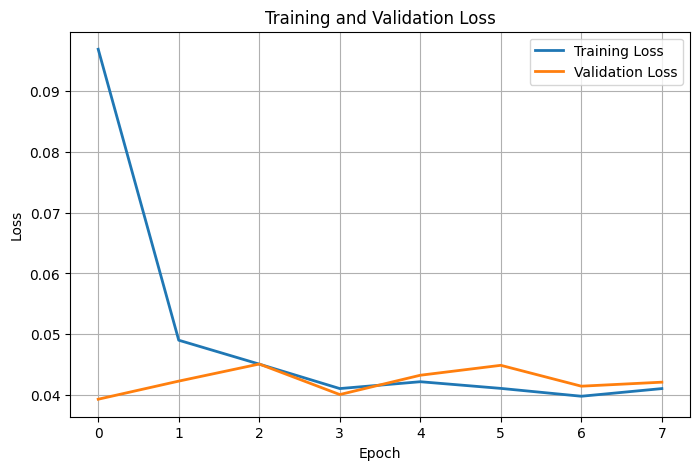

In [31]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(validation_losses, label='Validation Loss', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

In [32]:
model.eval()

predictions = []
targets = []

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = model(x_batch)

        predictions.append(
            y_pred.cpu()
        )

        targets.append(
            y_batch.cpu()
        )

predictions = torch.cat(
    predictions,
    dim=0
)

targets = torch.cat(
    targets,
    dim=0
)

print("Predictions:", predictions.shape)
print("Targets:", targets.shape)

Predictions: torch.Size([1623, 1])
Targets: torch.Size([1623, 1])


In [33]:
y_pred_scaled = predictions.numpy()
y_true_scaled = targets.numpy()

y_pred = y_scaler.inverse_transform(
    y_pred_scaled
).squeeze()

y_true = y_scaler.inverse_transform(
    y_true_scaled
).squeeze()

## 9. Test evaluation

Predictions are transformed from standardized units back to **degrees Celsius** before computing the final metrics. Performance is quantified using:

- **MSE**, which strongly penalizes large deviations;
- **RMSE**, expressed in degrees Celsius and therefore directly interpretable;
- **MAE**, the mean absolute temperature error;
- **R²**, which measures the fraction of target variance explained by the model.


The notebook therefore also evaluates every test `profile_id` separately. This avoids visually connecting independent experiments and makes it possible to associate each trajectory with its own RMSE, MAE and R².


In [34]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

y_pred_scaled = predictions.numpy()
y_true_scaled = targets.numpy()

y_pred_celsius = y_scaler.inverse_transform(
    y_pred_scaled
).squeeze()

y_true_celsius = y_scaler.inverse_transform(
    y_true_scaled
).squeeze()

mse = mean_squared_error(
    y_true_celsius,
    y_pred_celsius
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_true_celsius,
    y_pred_celsius
)

r2 = r2_score(
    y_true_celsius,
    y_pred_celsius
)

print(f"MSE:  {mse:.3f} °C²")
print(f"RMSE: {rmse:.3f} °C")
print(f"MAE:  {mae:.3f} °C")
print(f"R²:   {r2:.4f}")

MSE:  42.126 °C²
RMSE: 6.490 °C
MAE:  4.984 °C
R²:   0.8910


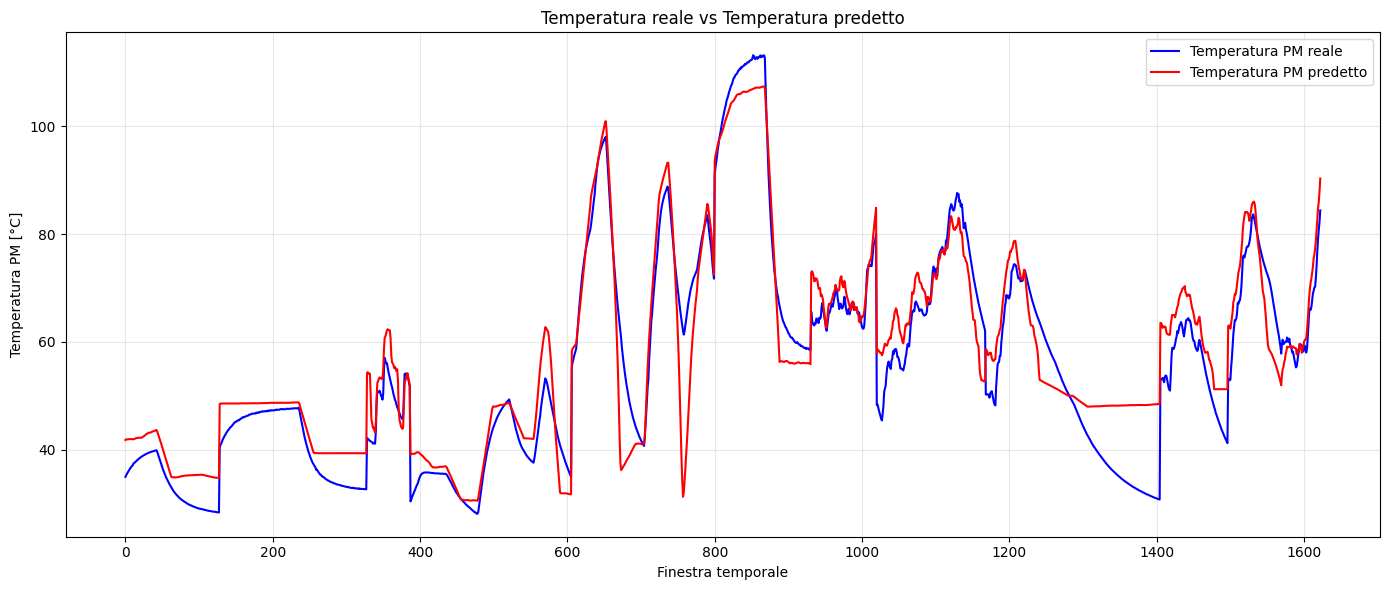

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_true_celsius,
    label="Temperatura PM reale",
    color="blue"
)

plt.plot(
    y_pred_celsius,
    label="Temperatura PM predetto",
    color="red"
)

plt.xlabel("Finestra temporale")
plt.ylabel("Temperatura PM [°C]")
plt.title("Temperatura reale vs Temperatura predetto")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

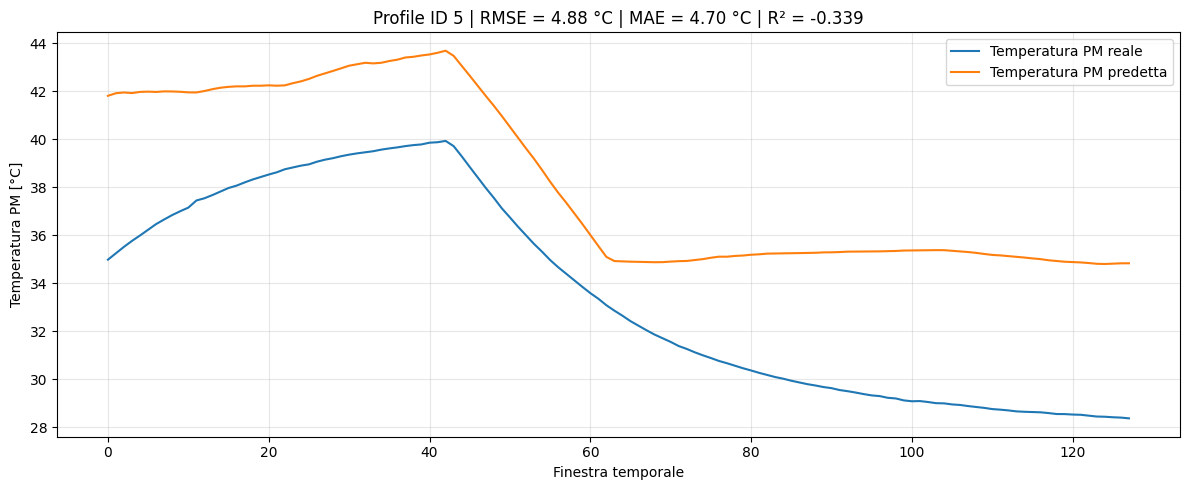

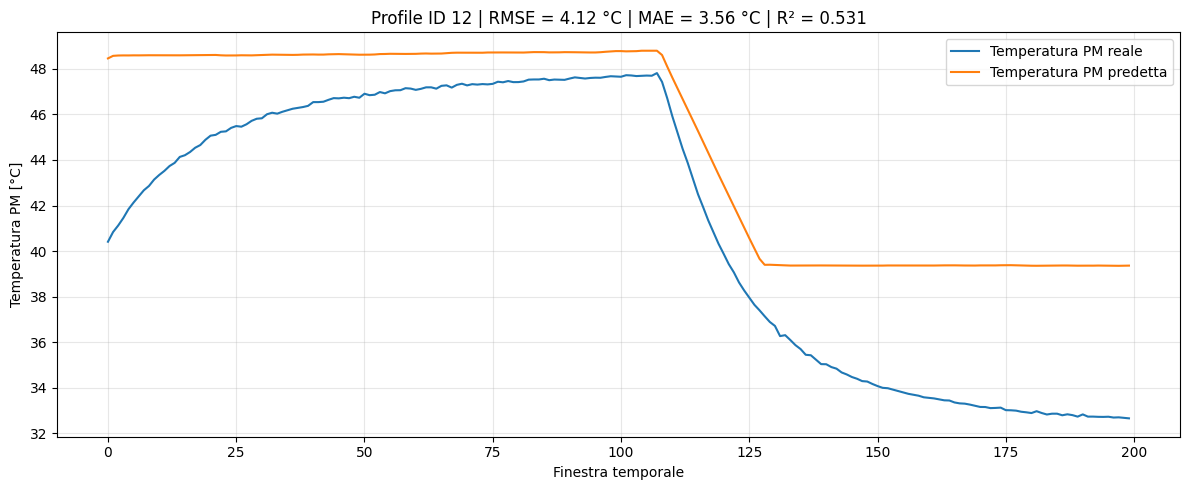

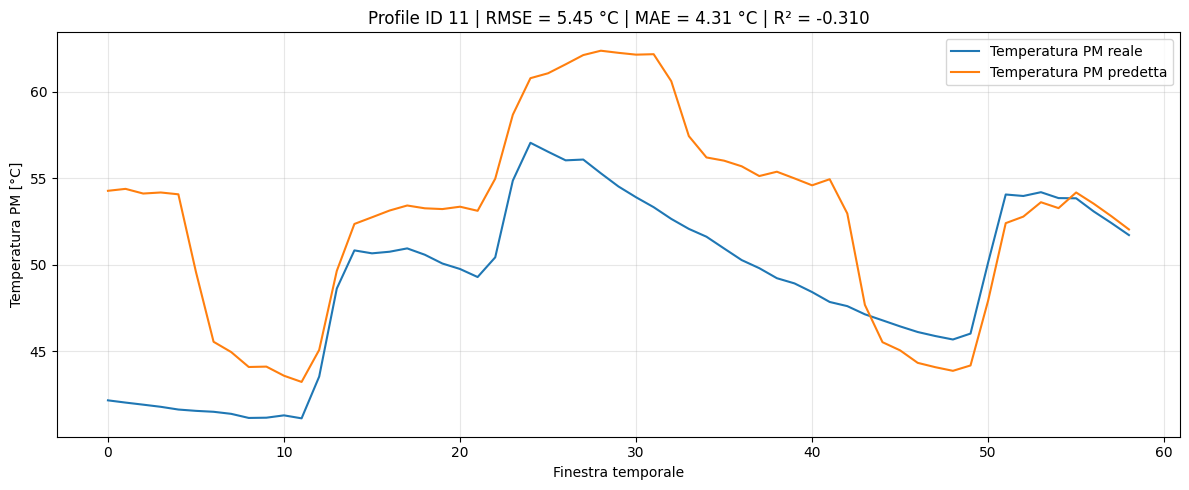

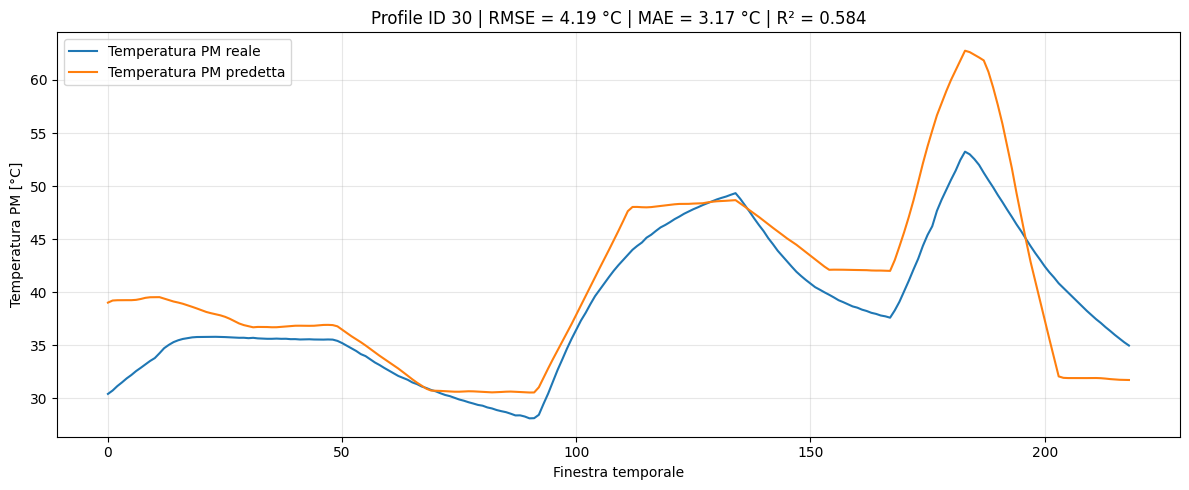

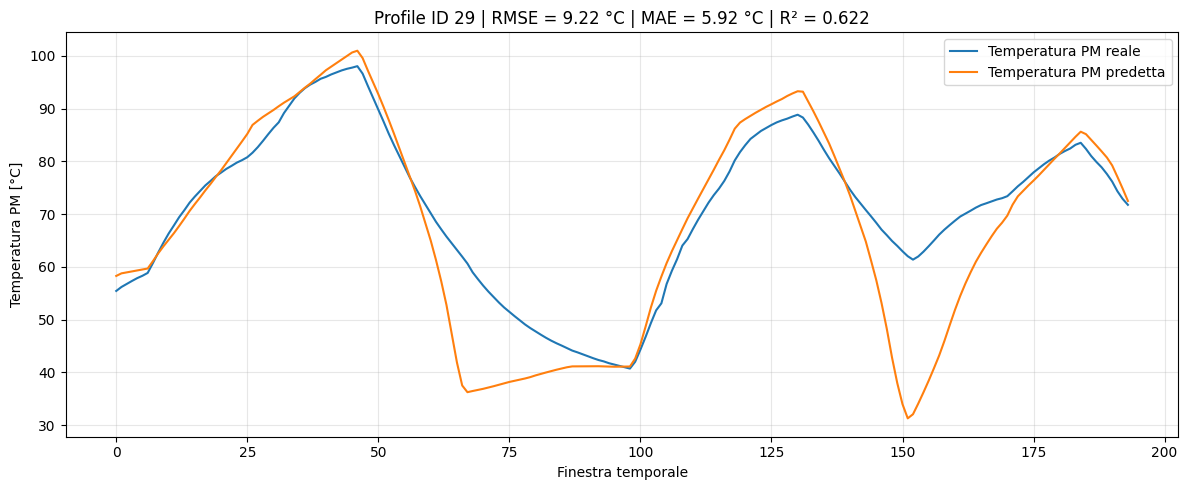

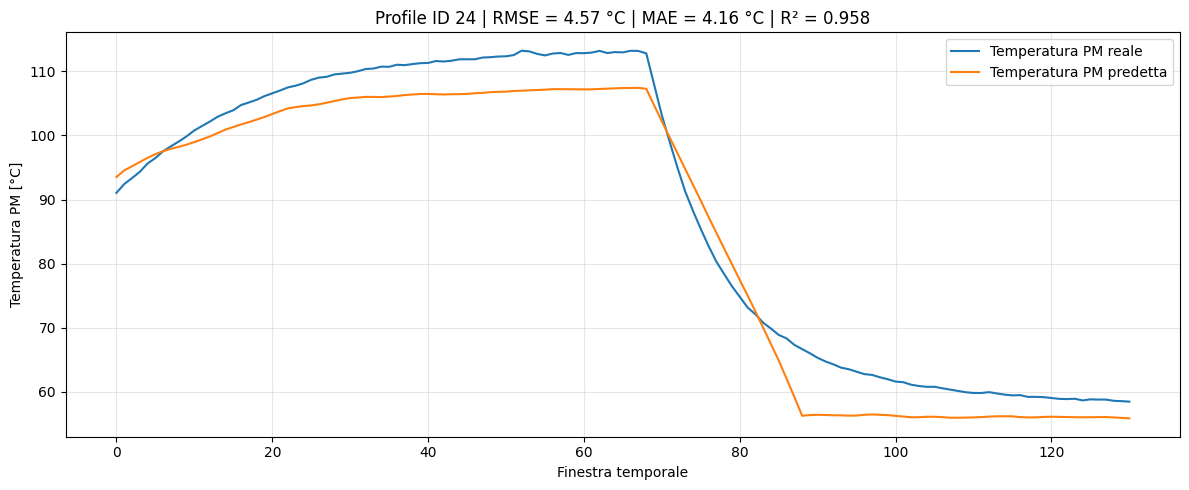

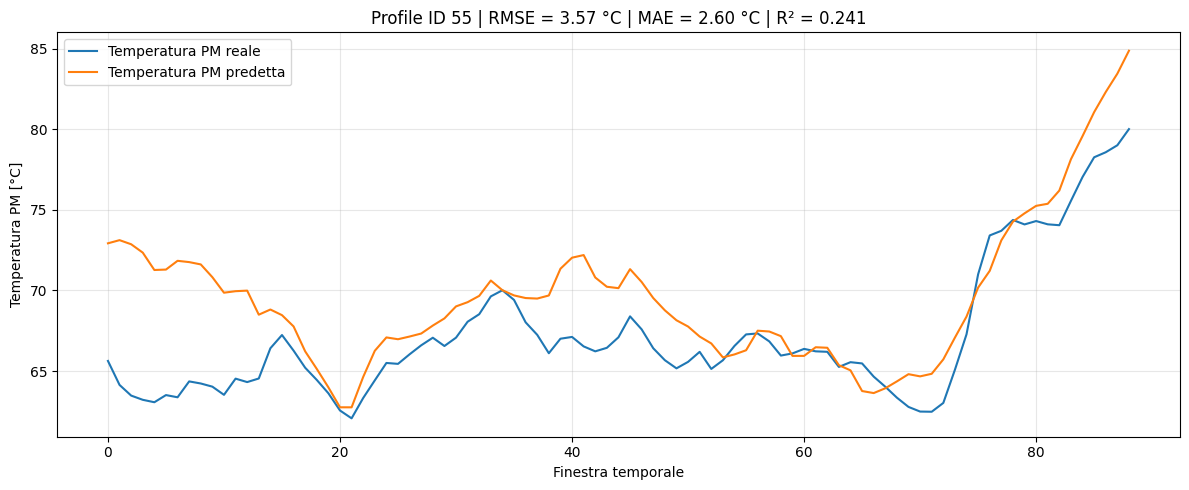

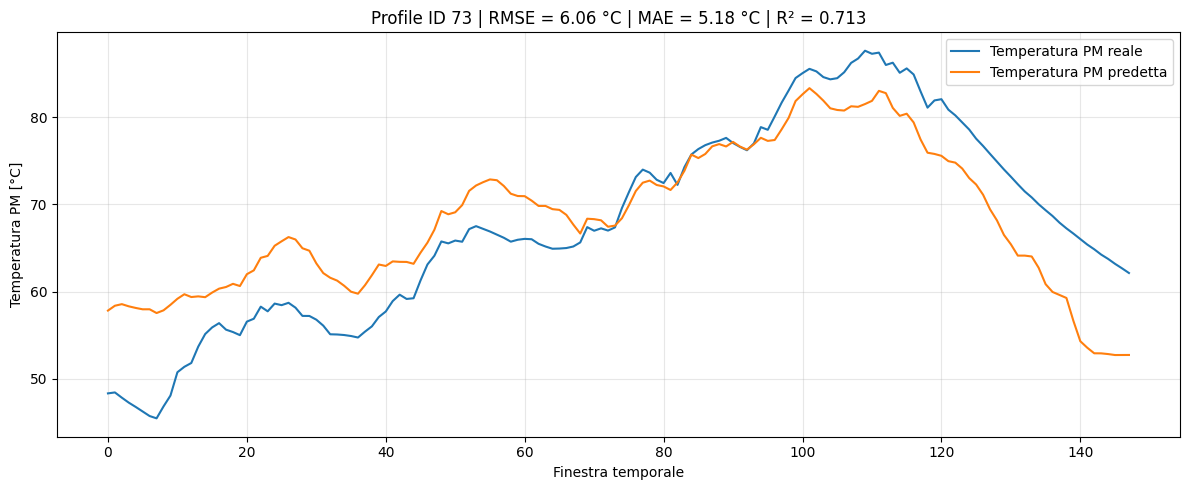

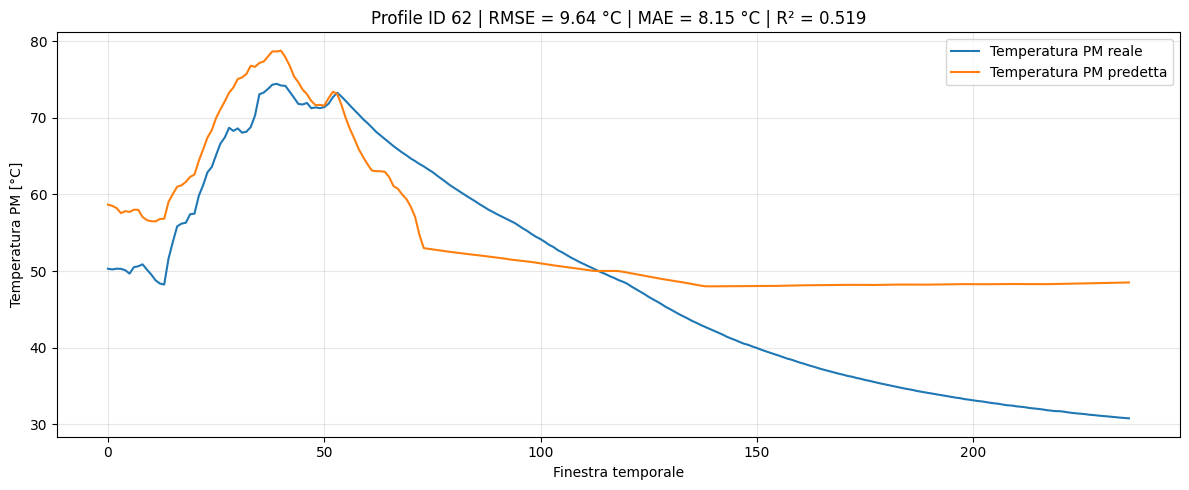

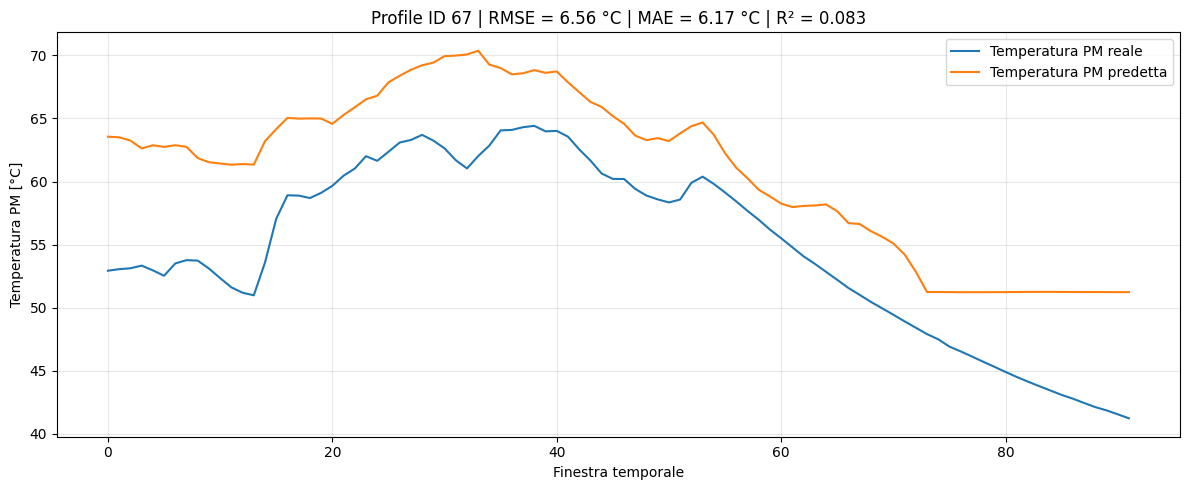

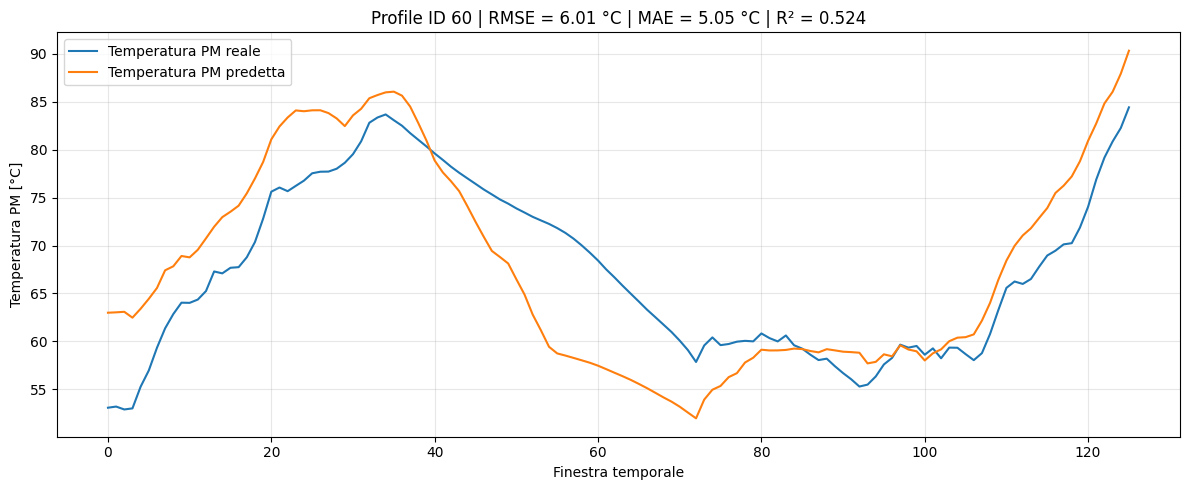

In [36]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# MODELLO IN MODALITÀ EVALUATION
# ============================================================

model.eval()


# ============================================================
# LOOP SU OGNI PROFILE_ID DEL TEST SET
# ============================================================

for profile_id, profile_df in test_df.groupby("profile_id", sort=False):

    # Salta eventuali profili più corti della finestra
    if len(profile_df) < window_size:
        continue


    # ========================================================
    # 1. SCALING
    # ========================================================

    x_profile = x_scaler.transform(
        profile_df[features]
    )

    y_profile = y_scaler.transform(
        profile_df[[target]]
    ).squeeze()


    # ========================================================
    # 2. CREAZIONE DATASET
    # ========================================================

    profile_dataset = TimeSeriesDataset(
        features=x_profile,
        targets=y_profile,
        window_size=window_size,
        stride=stride
    )

    profile_loader = DataLoader(
        profile_dataset,
        batch_size=32,
        shuffle=False
    )


    # ========================================================
    # 3. PREDICTION
    # ========================================================

    predictions = []
    targets = []

    with torch.no_grad():

        for x_batch, y_batch in profile_loader:

            x_batch = x_batch.to(device)

            y_pred = model(x_batch)

            predictions.append(
                y_pred.cpu()
            )

            targets.append(
                y_batch.cpu()
            )


    # Unisco tutti i batch
    predictions = torch.cat(predictions).numpy()
    targets = torch.cat(targets).numpy()


    # ========================================================
    # 4. INVERSE SCALING
    # ========================================================

    predictions = y_scaler.inverse_transform(
        predictions.reshape(-1, 1)
    ).squeeze()

    targets = y_scaler.inverse_transform(
        targets.reshape(-1, 1)
    ).squeeze()


    # ========================================================
    # 5. METRICHE DEL SINGOLO PROFILE_ID
    # ========================================================

    mse = mean_squared_error(
        targets,
        predictions
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        targets,
        predictions
    )

    r2 = r2_score(
        targets,
        predictions
    )


    # ========================================================
    # 6. PLOT
    # ========================================================

    plt.figure(figsize=(12, 5))

    plt.plot(
        targets,
        label="Temperatura PM reale"
    )

    plt.plot(
        predictions,
        label="Temperatura PM predetta"
    )

    plt.xlabel("Finestra temporale")

    plt.ylabel(
        "Temperatura PM [°C]"
    )

    # Metriche direttamente nel titolo
    plt.title(
        f"Profile ID {profile_id} | "
        f"RMSE = {rmse:.2f} °C | "
        f"MAE = {mae:.2f} °C | "
        f"R² = {r2:.3f}"
    )

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()